In [98]:
# Import necessary modules
import numpy as np
import datetime
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
from datetime import datetime, date
import pandas as pd


In [91]:
# Function to calculate yearly correlation matrix
def CalculateYearlyCorrelation(enso_indices, ao_indices, ice_indices, value_of_interest, years_of_data, study_sites):
    results = {}
    for year in years_of_data:
        for site in study_sites:
            entry_date = datetime(year=year, month=3, day=1)
            site_data = ice_indices.get(site, {}).get(entry_date, {})
            ice_value = site_data.get(value_of_interest[0], {}).get(value_of_interest[1])
            #print(ice_value)
            
            # Extract ENSO and AO values for the given year
            enso_values = enso_indices.get(datetime(year, 3, 1))
            ao_values = ao_indices.get(datetime(year, 3, 1))
            
           # Check if data exists and is the correct length
            if not enso_values or not ao_values or len(enso_values) != 13 or len(ao_values) != 13 or ice_value is None:
                print(f"Error: Number of indices for year {year} at site {site} do not match or missing ice value.")
                continue

            # Duplicate the ice value to match the array length
            ice_array = [ice_value] * 13
            #print(ice_array)
            
            # Combine into a matrix for correlation calculation
            data_matrix = np.array([enso_values, ao_values, ice_array])
            #print(data_matrix)
            
            # Calculate correlation matrix
            correlation_matrix = np.corrcoef(data_matrix)
            results[(year, site)] = correlation_matrix

    return results


In [92]:
def CalculateYearlyCovariance(enso_indices, ao_indices, ice_indices, value_of_interest, years_of_data, study_sites):
    results = {}
    for year in years_of_data:
        for site in study_sites:
            entry_date = datetime(year=year, month=3, day=1)
            site_data = ice_indices.get(site, {}).get(entry_date, {})
            ice_value = site_data.get(value_of_interest[0], {}).get(value_of_interest[1])
            
            # Extract ENSO and AO values for the given year
            enso_values = enso_indices.get(datetime(year, 3, 1))
            ao_values = ao_indices.get(datetime(year, 3, 1))
            
            # Check if data exists and is the correct length
            if not enso_values or not ao_values or len(enso_values) != 13 or len(ao_values) != 13 or ice_value is None:
                print(f"Error: Number of indices for year {year} at site {site} do not match or missing ice value.")
                continue

            # Duplicate the ice value to match the array length
            ice_array = [ice_value] * 13
            #print(ice_array)
            
            # Combine into a matrix for covariance calculation
            data_matrix = np.array([enso_values, ao_values, ice_array])

            # Calculate covariance matrix
            covariance_matrix = np.cov(data_matrix)
            results[(year, site)] = covariance_matrix

    return results

In [93]:
import matplotlib.pyplot as plt
import seaborn as sns

def visualize_heatmaps(matrix_dict, matrix_type='Matrix'):
    """
    Visualizes heatmaps for given matrices.

    Parameters:
    matrix_dict (dict): A dictionary of matrices where keys are tuples (year, site)
                        and values are the matrices to visualize.
    matrix_type (str): The type of matrix (e.g., 'Correlation', 'Covariance') for title purposes.
    """
    num_matrices = len(matrix_dict)
    fig, axes = plt.subplots(1, num_matrices, figsize=(5 * num_matrices, 5))

    for idx, ((year, site), matrix) in enumerate(matrix_dict.items()):
        ax = axes[idx] if num_matrices > 1 else axes
        sns.heatmap(matrix, annot=True, fmt=".2f", cmap='coolwarm', ax=ax,
                    cbar=True, square=True, linewidths=0.5)
        
        ax.set_title(f'{matrix_type} Matrix for {site} ({year})')
        ax.set_xticklabels(['ENSO', 'AO', 'Ice Index'], rotation=45)
        ax.set_yticklabels(['ENSO', 'AO', 'Ice Index'], rotation=0)

    plt.tight_layout()
    plt.show()


{(2000, 'Stebbins'): array([[ 1.00000000e+00,  1.03855982e-01,  0.00000000e+00],
       [ 1.03855982e-01,  1.00000000e+00, -2.29405547e-17],
       [ 0.00000000e+00, -2.29405547e-17,  1.00000000e+00]]), (2001, 'Stebbins'): array([[ 1.00000000e+00,  4.44727720e-01,  0.00000000e+00],
       [ 4.44727720e-01,  1.00000000e+00, -3.62791162e-17],
       [ 0.00000000e+00, -3.62791162e-17,  1.00000000e+00]])}
{(2000, 'Stebbins'): array([[ 6.11410256e-01,  6.29320513e-02,  0.00000000e+00],
       [ 6.29320513e-02,  6.00548410e-01, -1.02716264e-33],
       [ 0.00000000e+00, -1.02716264e-33,  3.33827857e-33]]), (2001, 'Stebbins'): array([[ 1.86974359e+00,  5.95986538e-01,  0.00000000e+00],
       [ 5.95986538e-01,  9.60511231e-01, -4.10865055e-33],
       [ 0.00000000e+00, -4.10865055e-33,  1.33531143e-32]])}


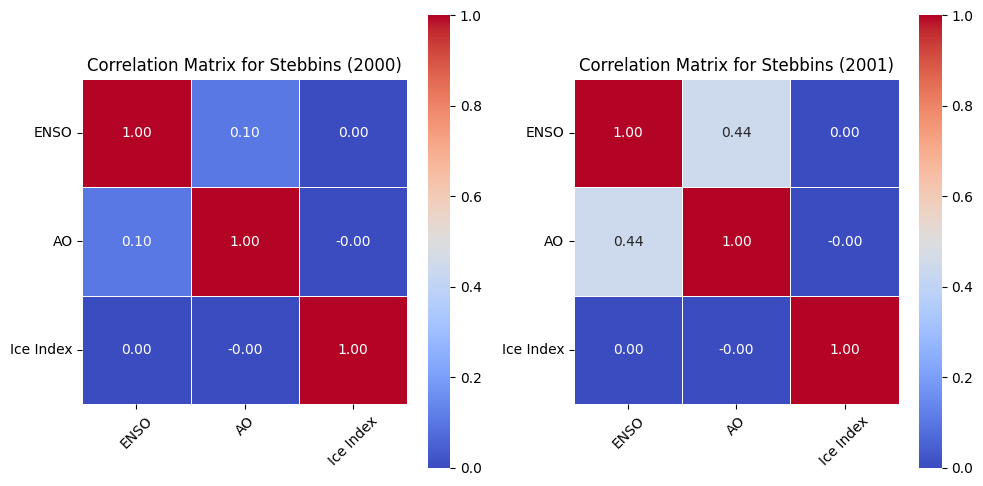

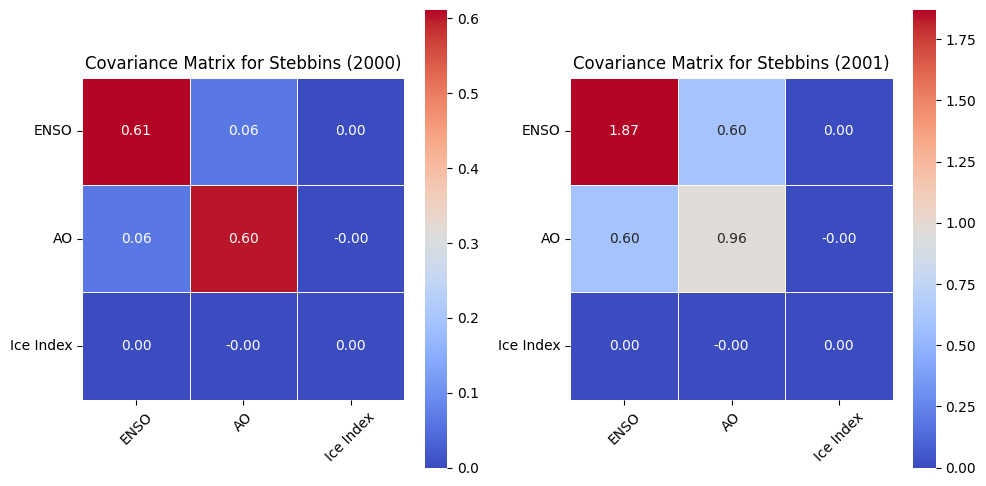

In [97]:
### Testing ###
"""
A space to test whether functions are working correctly.
This section should be commented out entirely once testing has been completed.
"""

# Define sample indices to test functions locally
ao_indices = {dt.datetime(2000, 3, 1, 0, 0): [-1.492, 0.284, 0.226, 0.707, -0.002, -0.672, 0.059, -0.006, 0.611, 1.043, 1.27, 1.076, -0.451], dt.datetime(2001, 3, 1, 0, 0): [-0.451, -0.279, 0.969, 0.586, -0.649, 0.144, 0.395, 0.317, -1.581, -2.354, -0.959, -0.622, -1.687]}
ice_indices = {'Stebbins': {dt.datetime(2000, 3, 1, 0, 0): {'SLIE_anomaly': {'index': -0.3713919937694287, 'actual_km_anomaly': -2.4020745070233502}, 'breakup_anomaly': {'index': 0.5844444444444444, 'actual_days_anomaly': 13.543478260869565}}, dt.datetime(2001, 3, 1, 0, 0): {'SLIE_anomaly': {'index': -0.8318790081077084, 'actual_km_anomaly': -8.14579473408959}, 'breakup_anomaly': {'index': 0.5577777777777778, 'actual_days_anomaly': 12.043478260869565}}}, 'Hooper Bay': {dt.datetime(2000, 3, 1, 0, 0): {'SLIE_anomaly': {'index': 0.660523074392061, 'actual_km_anomaly': 4.259097823342619}, 'breakup_anomaly': {'index': 0.5574712643678161, 'actual_days_anomaly': 14.5}}, dt.datetime(2001, 3, 1, 0, 0): {'SLIE_anomaly': {'index': -0.6749335738865974, 'actual_km_anomaly': -4.989954836107462}, 'breakup_anomaly': {'index': 0.2586206896551724, 'actual_days_anomaly': 5.5}}}}
enso_indices = {dt.datetime(2000, 3, 1, 0, 0): [-1.1, -0.7, 1.2, 0.8, 0.4, 1.4, 0.5, -0.3, -0.7, -0.7, 0.5, 0.2, -0.0], dt.datetime(2001, 3, 1, 0, 0): [-0.0, -0.8, 0.8, 1.2, 0.3, -0.4, 0.1, -1.5, -2.2, -2.4, 1.0, -2.9, 0.5]}

value_of_interest = ('SLIE_anomaly', 'index')
years_of_data = list(range(2000, 2002))
study_sites = ["Stebbins"]

# Check if CalculateYearlyCorrelation function works
corr_matrices = CalculateYearlyCorrelation(enso_indices, ao_indices, ice_indices, value_of_interest, years_of_data, study_sites)
print(corr_matrices)

# Check if CalculateYearlyCorrelation function works
cov_matrices = CalculateYearlyCovariance(enso_indices, ao_indices, ice_indices, value_of_interest, years_of_data, study_sites)
print(cov_matrices)

# Visualization of results using heatmaps --
# For correlation matrices
corr_matrices = CalculateYearlyCorrelation(enso_indices, ao_indices, ice_indices, value_of_interest, years_of_data, study_sites)
visualize_heatmaps(corr_matrices, 'Correlation')

# For covariance matrices
cov_matrices = CalculateYearlyCovariance(enso_indices, ao_indices, ice_indices, value_of_interest, years_of_data, study_sites)
visualize_heatmaps(cov_matrices, 'Covariance')